In [1]:
#3. Eğitim döngüsünü kur: önce tek bir minibatch'i overfit et, sonra bütün veriyi minibatch'lerle eğit. 
#Learning rate'i videodaki gibi tara ve iyi bir değer seç. Veriyi train / dev / test olarak böl, loss'u dev üzerinde raporla.
#libraries & data 
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

words = open('names.txt', 'r').read().splitlines()

In [2]:
#character mappings; i to s or vice versa
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}


In [3]:
block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words[:5]:
  
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    context = context[1:] + [ix] # crop and append   
X = torch.tensor(X)
Y = torch.tensor(Y)

In [4]:
#random first weights and biases
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn(6,100,generator=g)
b1 = torch.randn(100,generator=g)
W2 = torch.randn((100, 27),generator=g)
b2 = torch.randn(27,generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

In [5]:
#overfitted with using only first 5 word from data
for _ in range(1000):

    #forward pass
    emb = C[X]
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y)
    
    #backward pass 
    for p in parameters:
        p.grad = None
    loss.backward()
    
    #update rule
    for p in parameters:
        p.data += -0.1 * p.grad
print(loss.item())

0.2561384439468384


In [6]:
emb.shape

torch.Size([32, 3, 2])

In [7]:
block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words: #now full data with batches
  
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    context = context[1:] + [ix] # crop and append   
X = torch.tensor(X)
Y = torch.tensor(Y)

In [8]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn(6,100,generator=g)
b1 = torch.randn(100,generator=g)
W2 = torch.randn((100, 27),generator=g)
b2 = torch.randn(27,generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

In [9]:
#training with minibatches instead of whole batch once
for _ in range(1000):
    #minibatch creation
    ix = torch.randint(0, X.shape[0],(32,),generator=g)

    #forward pass
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    #backward pass 
    for p in parameters:
        p.grad = None
    loss.backward()
    
    #update rule
    for p in parameters:
        p.data += -0.1 * p.grad
print(loss.item())

2.440699577331543


In [10]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [11]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn(6,100,generator=g)
b1 = torch.randn(100,generator=g)
W2 = torch.randn((100, 27),generator=g)
b2 = torch.randn(27,generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

In [12]:
lri=[]
lossi=[]

for i in range(1000):
  
  # minibatch construct
  ix = torch.randint(0, X.shape[0], (32,),generator=g)
  
  # forward pass
  emb = C[X[ix]] 
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
  logits = h @ W2 + b2 
  loss = F.cross_entropy(logits, Y[ix])

  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = lrs[i]
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  lri.append(lre[i])
  lossi.append(loss.item())

#print(loss.item())

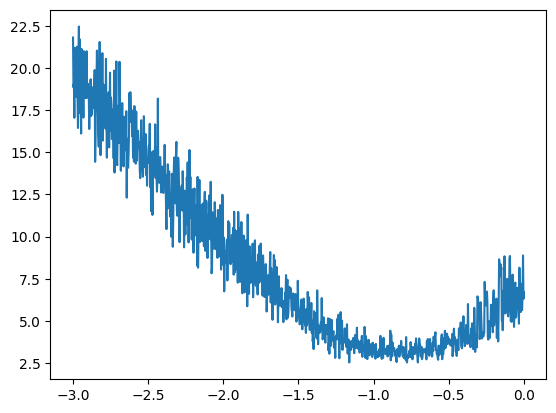

In [13]:
plt.plot(lri,lossi)

In [14]:
#10^-0.8 - 10^-1 seem cool for lr.

In [15]:
#splitting data as train/val/test part
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [16]:
#resetting net again.
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn(6,100,generator=g)
b1 = torch.randn(100,generator=g)
W2 = torch.randn((100, 27),generator=g)
b2 = torch.randn(27,generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

In [17]:
#training our model only with train set
for i in range(50000):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,),generator=g)
  
  # forward pass
  emb = C[Xtr[ix]] 
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
  logits = h @ W2 + b2 
  loss = F.cross_entropy(logits, Ytr[ix])

  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1
  for p in parameters:
    p.data += -lr * p.grad
    
      
print(loss.item())

2.2465076446533203


In [18]:
#reporting devs loss
emb = C[Xdev]
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits,Ydev)
print(f'dev loss= {loss}')

dev loss= 2.3654894828796387


In [20]:
#reporting train loss
emb = C[Xtr]
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits,Ytr)
print(f'train loss= {loss}')

train loss= 2.3702304363250732


In [21]:
#almost same loss both sets. we need bigger net